# Uncertainty-Aware and Differentially Private Federated Learning for Non-IID ECG Classification

**Course:** Intelligent System Design
**Dataset:** PTB-XL

## Group Members

1. **Wijerathne G. P. W. P.** — EG/2021/4871
2. **Randil K. A. G. S.** — EG/2021/4745
3. **Muhammed M. I.** — EG/2021/4679
4. **Husain M. T. M. S. A.** — EG/2021/4558

**Submission Date:** - 03.08.2026





## Abstract

This project focuses on privacy-preserving ECG classification using federated learning and differential privacy. The PTB-XL dataset was used to classify ECG records into five diagnostic classes: NORM, MI, STTC, CD, and HYP. Four non-IID hospitals were simulated, and each hospital trained a local 1D CNN without sharing raw patient data. Several methods were compared, including centralized training, FedAvg, uncertainty-aware FedAvg, DP-FedAvg, and DP-UA-FedAvg. Standard FedAvg achieved performance close to the centralized model, while differential privacy reduced the model performance because of gradient clipping and added noise. Class-specific threshold calibration improved the DP-FedAvg Macro-F1 score from 0.2750 to 0.5341 without retraining the model or increasing the privacy budget. The results show that federated learning can support collaborative ECG classification, but there is still a clear trade-off between privacy and model performance


## 1. Introduction and Objectives

Hospitals hold sensitive ECG data that cannot always be pooled centrally. Federated learning enables collaborative training while keeping raw ECG records local. Differential privacy further limits the influence of any one ECG record.

### Objectives
- Build a compact 1D CNN for five-class multi-label ECG classification.
- Simulate four non-IID hospitals.
- Compare centralized, federated, uncertainty-aware, and private methods.
- Study the privacy–utility trade-off.
- Apply validation-based class-specific threshold calibration.


In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError(
        "Launch Jupyter from the project root or place this notebook in notebooks/."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Project root: E:\Intelligent system design\Uncertainty-Aware-and-Differentially-Private-Federated-Learning-for-Non-IID-ECG-Classification
Python: 3.12.7
PyTorch: 2.13.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


## 3. Dataset Description and EDA

PTB-XL 100 Hz records contain 12 leads and 1,000 samples per lead. The output classes are NORM, MI, STTC, CD, and HYP. This is a multi-label task, so one ECG may have several positive labels.


Metadata shape: (21388, 14)


,patient_id,age,sex,height,weight,strat_fold,split,filename_lr,diagnostic_superclasses,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,3,train,records100/00000/00001_lr,['NORM'],1.0,0.0,0.0,0.0,0.0
2,13243.0,19.0,0,NaN,70.0,2,train,records100/00000/00002_lr,['NORM'],1.0,0.0,0.0,0.0,0.0
3,20372.0,37.0,1,NaN,69.0,5,train,records100/00000/00003_lr,['NORM'],1.0,0.0,0.0,0.0,0.0
4,17014.0,24.0,0,NaN,82.0,3,train,records100/00000/00004_lr,['NORM'],1.0,0.0,0.0,0.0,0.0
5,17448.0,19.0,1,NaN,70.0,4,train,records100/00000/00005_lr,['NORM'],1.0,0.0,0.0,0.0,0.0


,split,records
0,train,17084
1,test,2158
2,validation,2146


,positive_records
NORM,9514.0
MI,5469.0
STTC,5235.0
CD,4898.0
HYP,2649.0


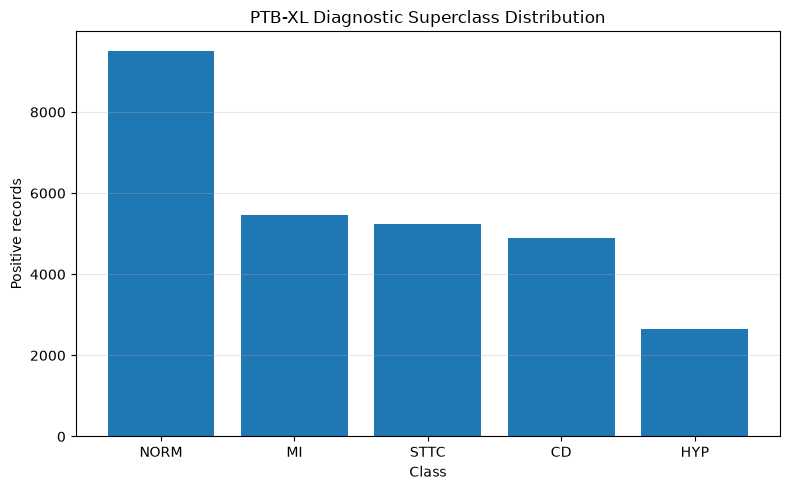

In [2]:
from src.data.ecg_dataset import DEFAULT_CLASS_NAMES, PTBXLDataset
from src.data.paths import PROCESSED_METADATA_PATH, PTBXL_ROOT

CLASS_NAMES = list(DEFAULT_CLASS_NAMES)
metadata = pd.read_csv(PROCESSED_METADATA_PATH, index_col="ecg_id")

print("Metadata shape:", metadata.shape)
display(metadata.head())

split_counts = metadata["split"].value_counts().rename_axis("split").reset_index(name="records")
display(split_counts)

class_counts = metadata[CLASS_NAMES].sum().sort_values(ascending=False)
display(class_counts.rename("positive_records").to_frame())

figure, axis = plt.subplots(figsize=(8, 5))
axis.bar(class_counts.index, class_counts.values)
axis.set_title("PTB-XL Diagnostic Superclass Distribution")
axis.set_xlabel("Class")
axis.set_ylabel("Positive records")
axis.grid(axis="y", alpha=0.3)
figure.tight_layout()
plt.show()


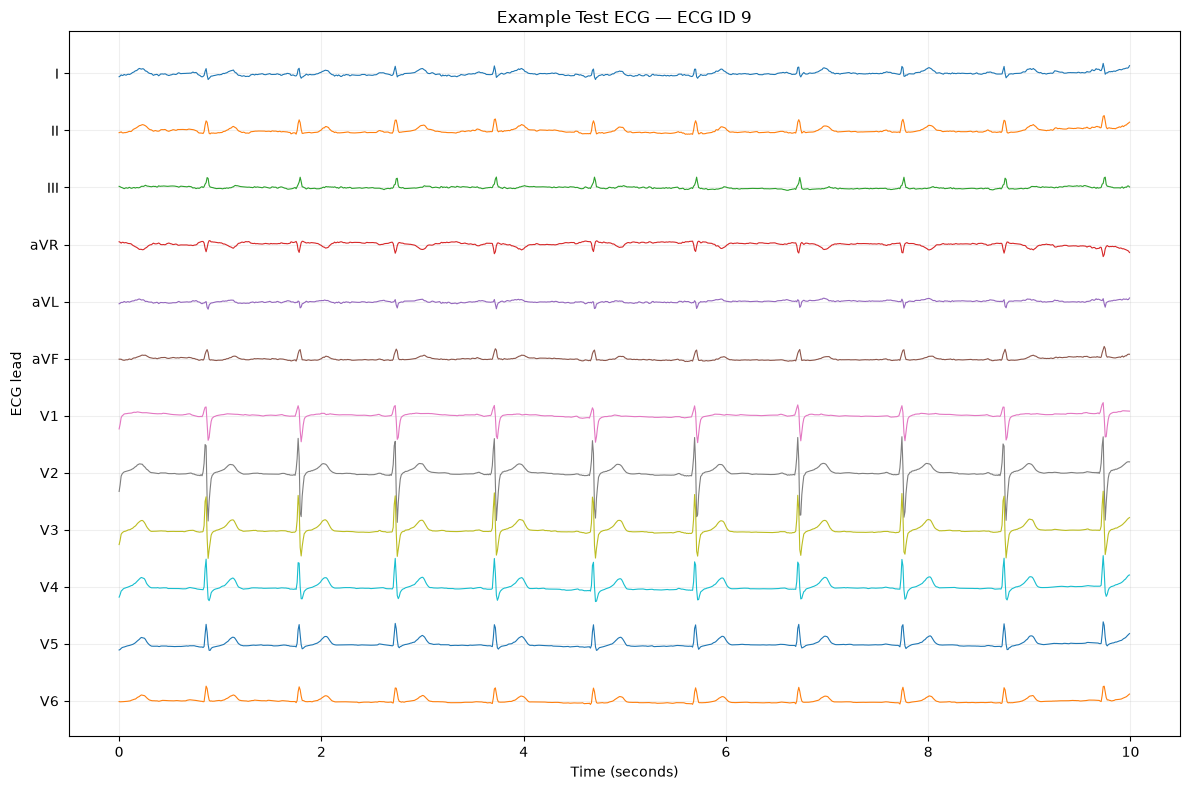

True labels: ['NORM']


In [3]:
test_metadata = metadata[metadata["split"] == "test"].copy()

test_dataset = PTBXLDataset(
    metadata=test_metadata,
    dataset_root=PTBXL_ROOT,
    class_names=CLASS_NAMES,
    normalize_per_record=False,
)

signal, target = test_dataset[0]
signal = torch.as_tensor(signal).cpu().numpy()
target = torch.as_tensor(target).cpu().numpy().astype(int)

lead_names = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]
time_seconds = np.arange(signal.shape[1]) / 100.0
scale = float(np.percentile(np.abs(signal), 99))
scale = scale if scale > 0 else 1.0
offsets = np.arange(12)[::-1] * scale * 3.0

figure, axis = plt.subplots(figsize=(12, 8))
for i, lead in enumerate(lead_names):
    axis.plot(time_seconds, signal[i] + offsets[i], linewidth=0.8)

axis.set_yticks(offsets)
axis.set_yticklabels(lead_names)
axis.set_xlabel("Time (seconds)")
axis.set_ylabel("ECG lead")
axis.set_title(f"Example Test ECG — ECG ID {test_metadata.index[0]}")
axis.grid(alpha=0.2)
figure.tight_layout()
plt.show()

true_labels = [name for name, value in zip(CLASS_NAMES, target) if int(value) == 1]
print("True labels:", true_labels)


## 4. Preprocessing and Non-IID Hospitals

Describe patient-level splitting, superclass label mapping, waveform loading, and the four non-IID hospital partitions.

| Hospital | Records | Patients |
|---|---:|---:|
| Hospital 0 | 8,460 | 7,328 |
| Hospital 1 | 3,931 | 3,488 |
| Hospital 2 | 3,349 | 2,919 |
| Hospital 3 | 1,344 | 1,088 |


## 5. Model Architecture

Each hospital used a local copy of the same DP-compatible 1D CNN:

- Conv1d 12→32, kernel 7
- GroupNorm, ReLU, MaxPool
- Conv1d 32→64, kernel 5
- GroupNorm, ReLU, MaxPool
- Conv1d 64→128, kernel 3
- GroupNorm, ReLU
- Adaptive average pooling
- Dropout 0.3
- Linear 128→5


In [4]:
from src.federated.dp_client import create_dp_compatible_ecg_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_dp_compatible_ecg_model(device=device)

print(model)
print("Total parameters:", f"{sum(p.numel() for p in model.parameters()):,}")


ECG1DCNN(
  (features): Sequential(
    (0): Conv1d(12, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (5): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (9): GroupNorm(8, 128, eps=1e-05, affine=True, bias=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=5, bias=True)
)
Total parameters: 38,597


## 6. Methods

### Centralized CNN
All training records are pooled and used to train one model.

### Standard FedAvg
Each hospital trains locally and the server aggregates using sample-count weights.

### Compatible FedAvg
The GroupNorm architecture is trained without DP to isolate architecture effects.

### UA-FedAvg
Client updates are weighted using sample count and MC-dropout uncertainty.

### DP-FedAvg
Each hospital uses DP-SGD with per-example clipping and Gaussian noise, followed by standard FedAvg.

### DP-UA-FedAvg
DP-SGD local training is combined with uncertainty-aware aggregation.


## 7. Differential Privacy Configuration

- Noise multiplier: 1.0
- Maximum gradient norm: 1.0
- Delta: 1e-5
- Local epochs: 1
- Batch size: 64
- Learning rate: 0.001
- Record-level DP-SGD
- Early stopping using validation loss


## 8. Final Fixed-Threshold Results

Before running this cell, ensure `results/tables/final_model_comparison.csv` contains the correct centralized test values from the authoritative centralized test evaluation.


,method,training_type,best_round_or_epoch,test_loss,test_macro_f1,test_weighted_f1,test_macro_auroc,reported_epsilon,delta,privacy_enabled,uncertainty_weighting,notes
0,Centralized CNN,centralized,10,0.308395,0.668600,0.721600,0.896400,NaN,NaN,False,False,Centralized upper-performance baseline.
1,Standard FedAvg,federated,15,0.333644,0.633300,0.690000,0.877100,NaN,NaN,False,False,Sample-count-weighted federated baseline.
2,Compatible FedAvg,federated-control,15,0.333640,0.633300,0.689900,0.877100,NaN,NaN,False,False,Non-private control using the Opacus-compatibl...
3,UA-FedAvg,federated,9,0.352530,0.613400,0.667700,0.865800,NaN,NaN,False,True,Inverse MC-dropout uncertainty-aware aggregation.
4,DP-FedAvg,private-federated,9,0.487335,0.275000,0.380300,0.771100,5.455118,0.00001,True,False,DP-SGD with noise multiplier 1.0 and clipping ...
5,DP-UA-FedAvg,private-uncertainty-federated,8,0.484302,0.245298,0.352366,0.762235,5.261606,0.00001,True,True,DP-SGD local training combined with inverse MC...


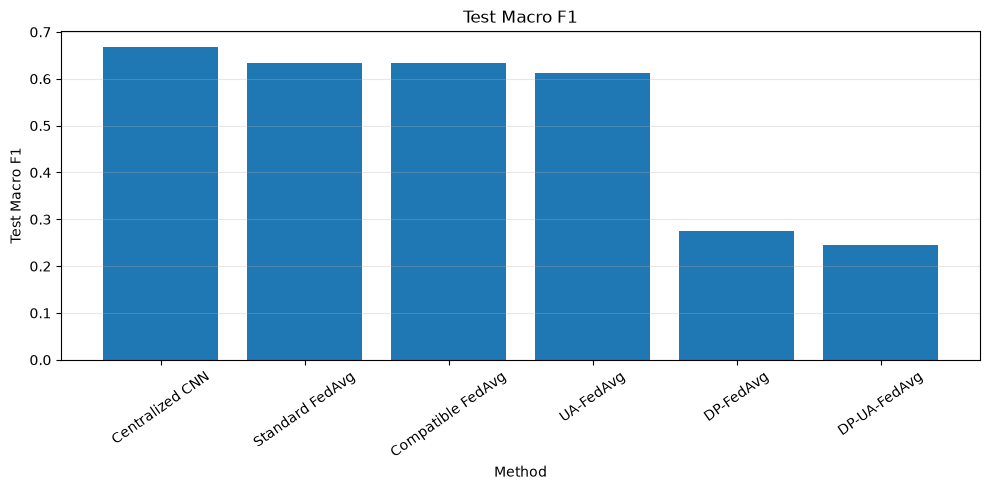

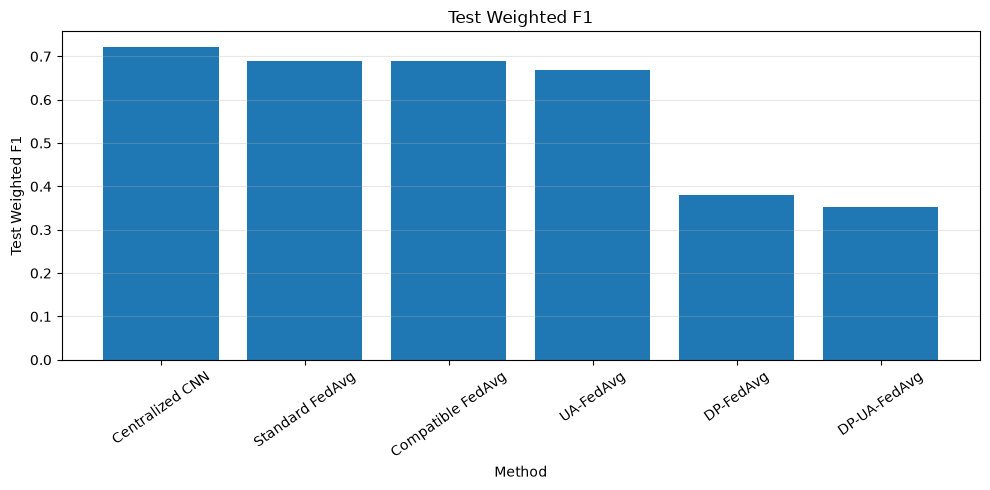

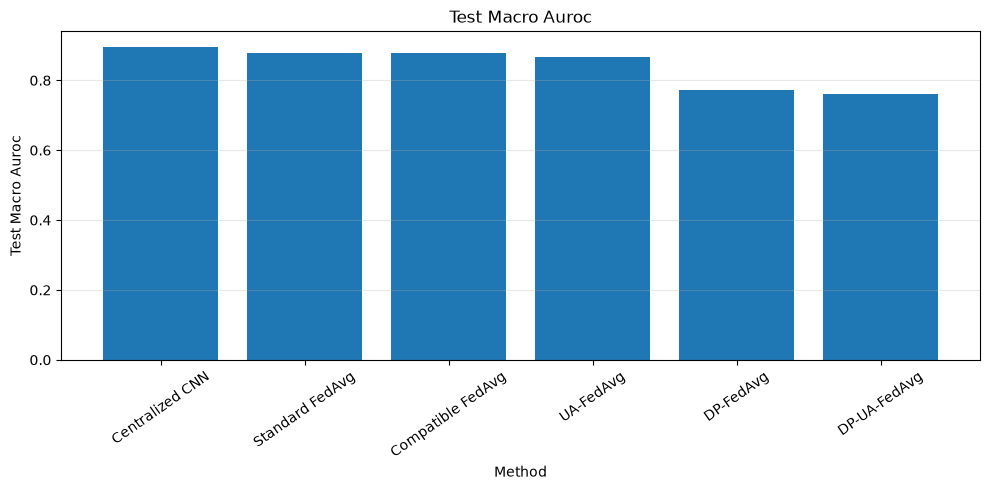

In [5]:
comparison_path = PROJECT_ROOT / "results" / "tables" / "final_model_comparison.csv"
comparison = pd.read_csv(comparison_path)
display(comparison)

for metric in ["test_macro_f1", "test_weighted_f1", "test_macro_auroc"]:
    figure, axis = plt.subplots(figsize=(10, 5))
    axis.bar(comparison["method"], comparison[metric])
    axis.set_title(metric.replace("_", " ").title())
    axis.set_xlabel("Method")
    axis.set_ylabel(metric.replace("_", " ").title())
    axis.tick_params(axis="x", rotation=35)
    axis.grid(axis="y", alpha=0.3)
    figure.tight_layout()
    plt.show()


## 9. DP-FedAvg Threshold Calibration

Class-specific thresholds were selected using only the validation split and frozen before test evaluation. This changed binary decisions but did not retrain the model, alter AUROC, or consume additional privacy budget.


,class_name,fixed_threshold,calibrated_threshold,validation_f1_fixed,validation_f1_calibrated
0,NORM,0.5,0.45,0.772938,0.773491
1,MI,0.5,0.21,0.420927,0.572763
2,STTC,0.5,0.15,0.216134,0.563150
3,CD,0.5,0.14,0.000000,0.500421
4,HYP,0.5,0.09,0.000000,0.324805


,method,split,threshold_type,macro_f1,weighted_f1,macro_auroc
0,DP-FedAvg,validation,fixed_0.5,0.282000,0.387500,0.778445
1,DP-FedAvg,validation,class_specific,0.546926,0.603042,0.778445
2,DP-FedAvg,test,fixed_0.5,0.275000,0.380282,0.771104
3,DP-FedAvg,test,class_specific,0.534134,0.588602,0.771104


,class_name,calibrated_threshold,test_f1_fixed,test_f1_calibrated,test_f1_change,test_auroc
0,NORM,0.45,0.755985,0.758808,0.002822,0.859491
1,MI,0.21,0.387173,0.557887,0.170713,0.772847
2,STTC,0.15,0.231839,0.527571,0.295732,0.775428
3,CD,0.14,0.000000,0.489002,0.489002,0.736495
4,HYP,0.09,0.000000,0.337403,0.337403,0.711258


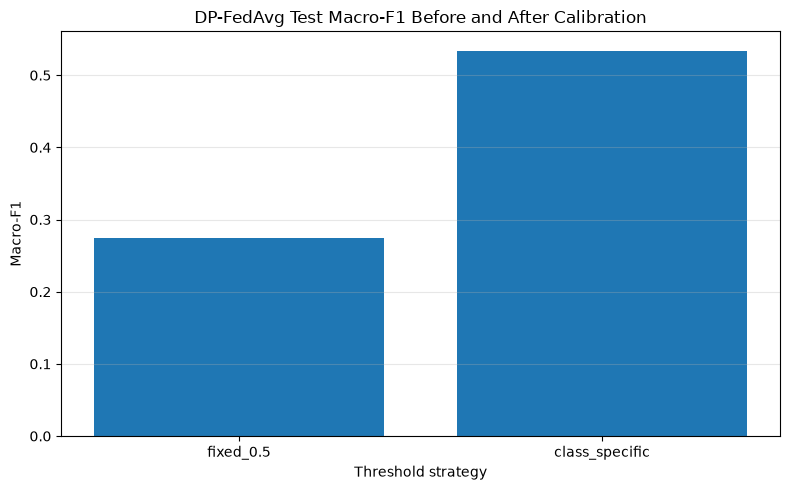

In [6]:
calibration_dir = PROJECT_ROOT / "results" / "threshold_calibration" / "dp_fedavg"

thresholds_table = pd.read_csv(calibration_dir / "class_thresholds.csv")
calibration_metrics = pd.read_csv(calibration_dir / "metrics_comparison.csv")
per_class = pd.read_csv(calibration_dir / "test_per_class_comparison.csv")

display(thresholds_table)
display(calibration_metrics)
display(per_class)

test_rows = calibration_metrics[calibration_metrics["split"] == "test"]

figure, axis = plt.subplots(figsize=(8, 5))
axis.bar(test_rows["threshold_type"], test_rows["macro_f1"])
axis.set_title("DP-FedAvg Test Macro-F1 Before and After Calibration")
axis.set_xlabel("Threshold strategy")
axis.set_ylabel("Macro-F1")
axis.grid(axis="y", alpha=0.3)
figure.tight_layout()
plt.show()


In [7]:
prediction_path = calibration_dir / "test_predictions_calibrated.csv"
predictions = pd.read_csv(prediction_path)

match_mask = np.ones(len(predictions), dtype=bool)
for class_name in CLASS_NAMES:
    match_mask &= (
        predictions[f"{class_name}_true"].astype(int)
        == predictions[f"{class_name}_predicted"].astype(int)
    )

exact_matches = int(match_mask.sum())
subset_accuracy = exact_matches / len(predictions)

subset_summary = pd.DataFrame({
    "test_records": [len(predictions)],
    "exact_matches": [exact_matches],
    "subset_accuracy": [subset_accuracy],
    "subset_accuracy_percent": [100 * subset_accuracy],
})

display(subset_summary)


,test_records,exact_matches,subset_accuracy,subset_accuracy_percent
0,2158,839,0.388786,38.878591


### Calibrated DP-FedAvg Results

- NORM threshold: 0.45
- MI threshold: 0.21
- STTC threshold: 0.15
- CD threshold: 0.14
- HYP threshold: 0.09
- Macro-F1: 0.5341
- Weighted-F1: 0.5886
- Macro-AUROC: 0.7711
- Subset accuracy: 38.88%
- Epsilon: 5.4551
- Delta: 1e-5


## 10. Example Predictions


Correct multi-label example — ECG 5163


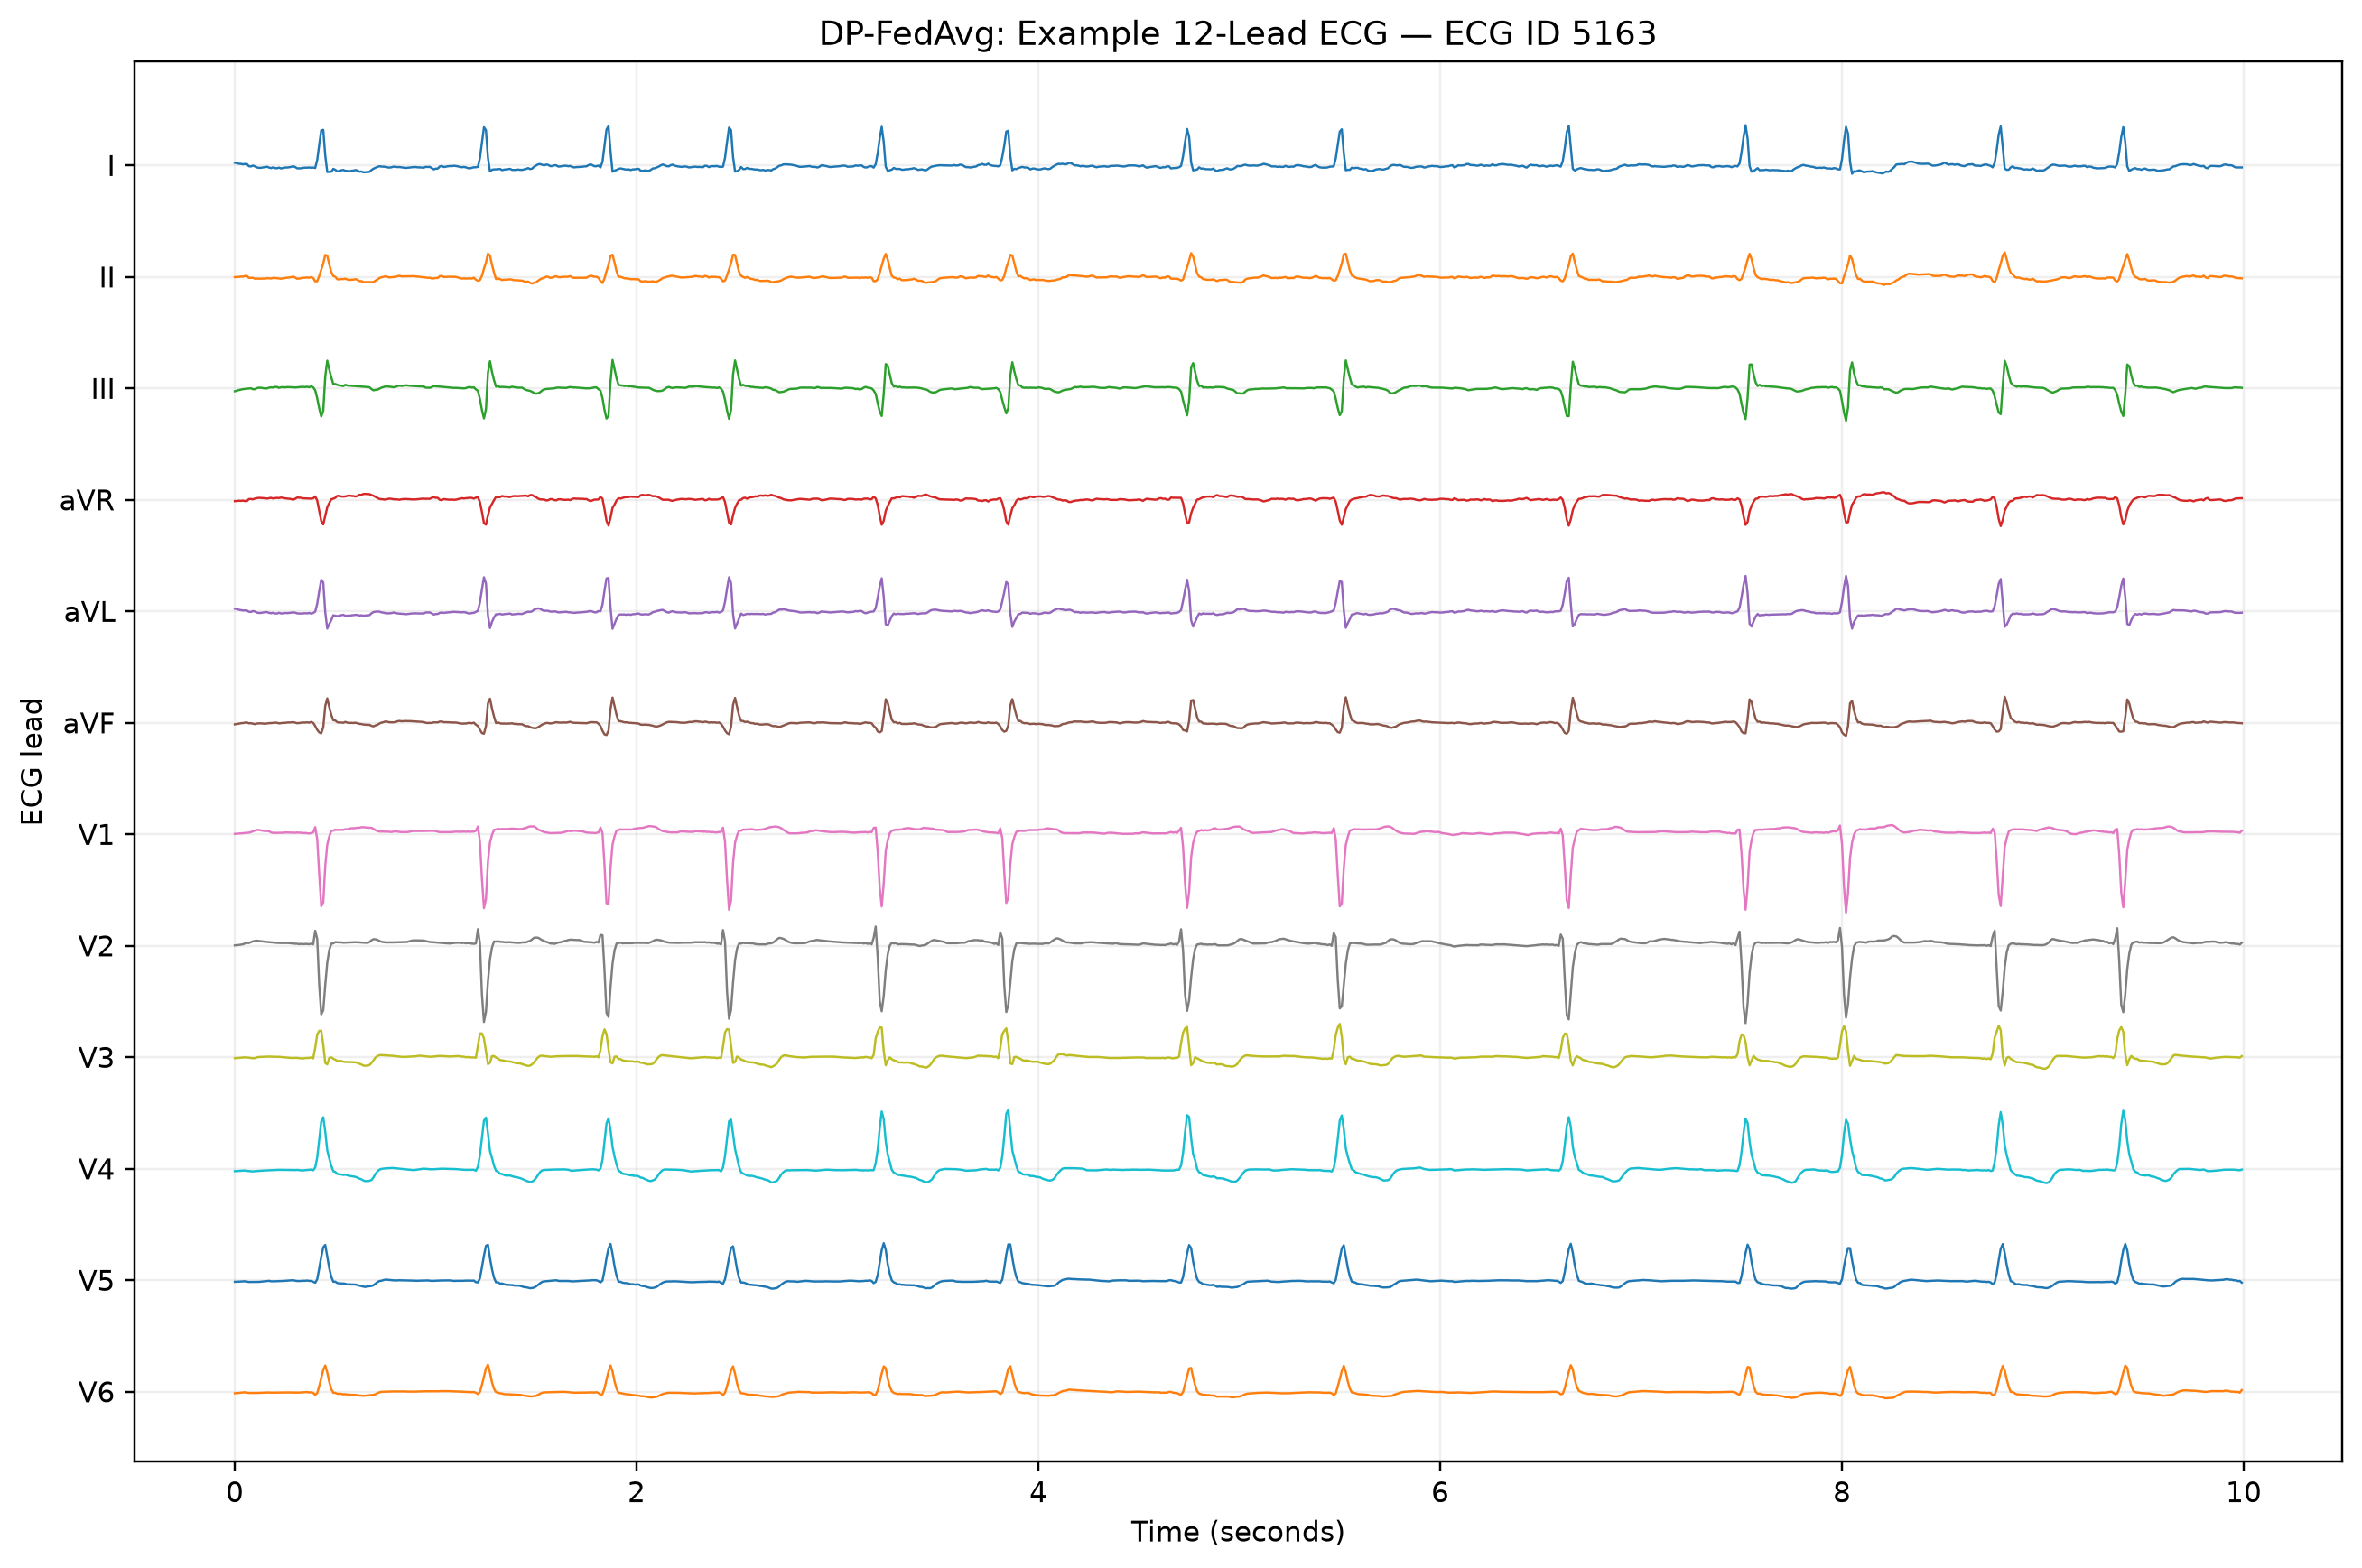

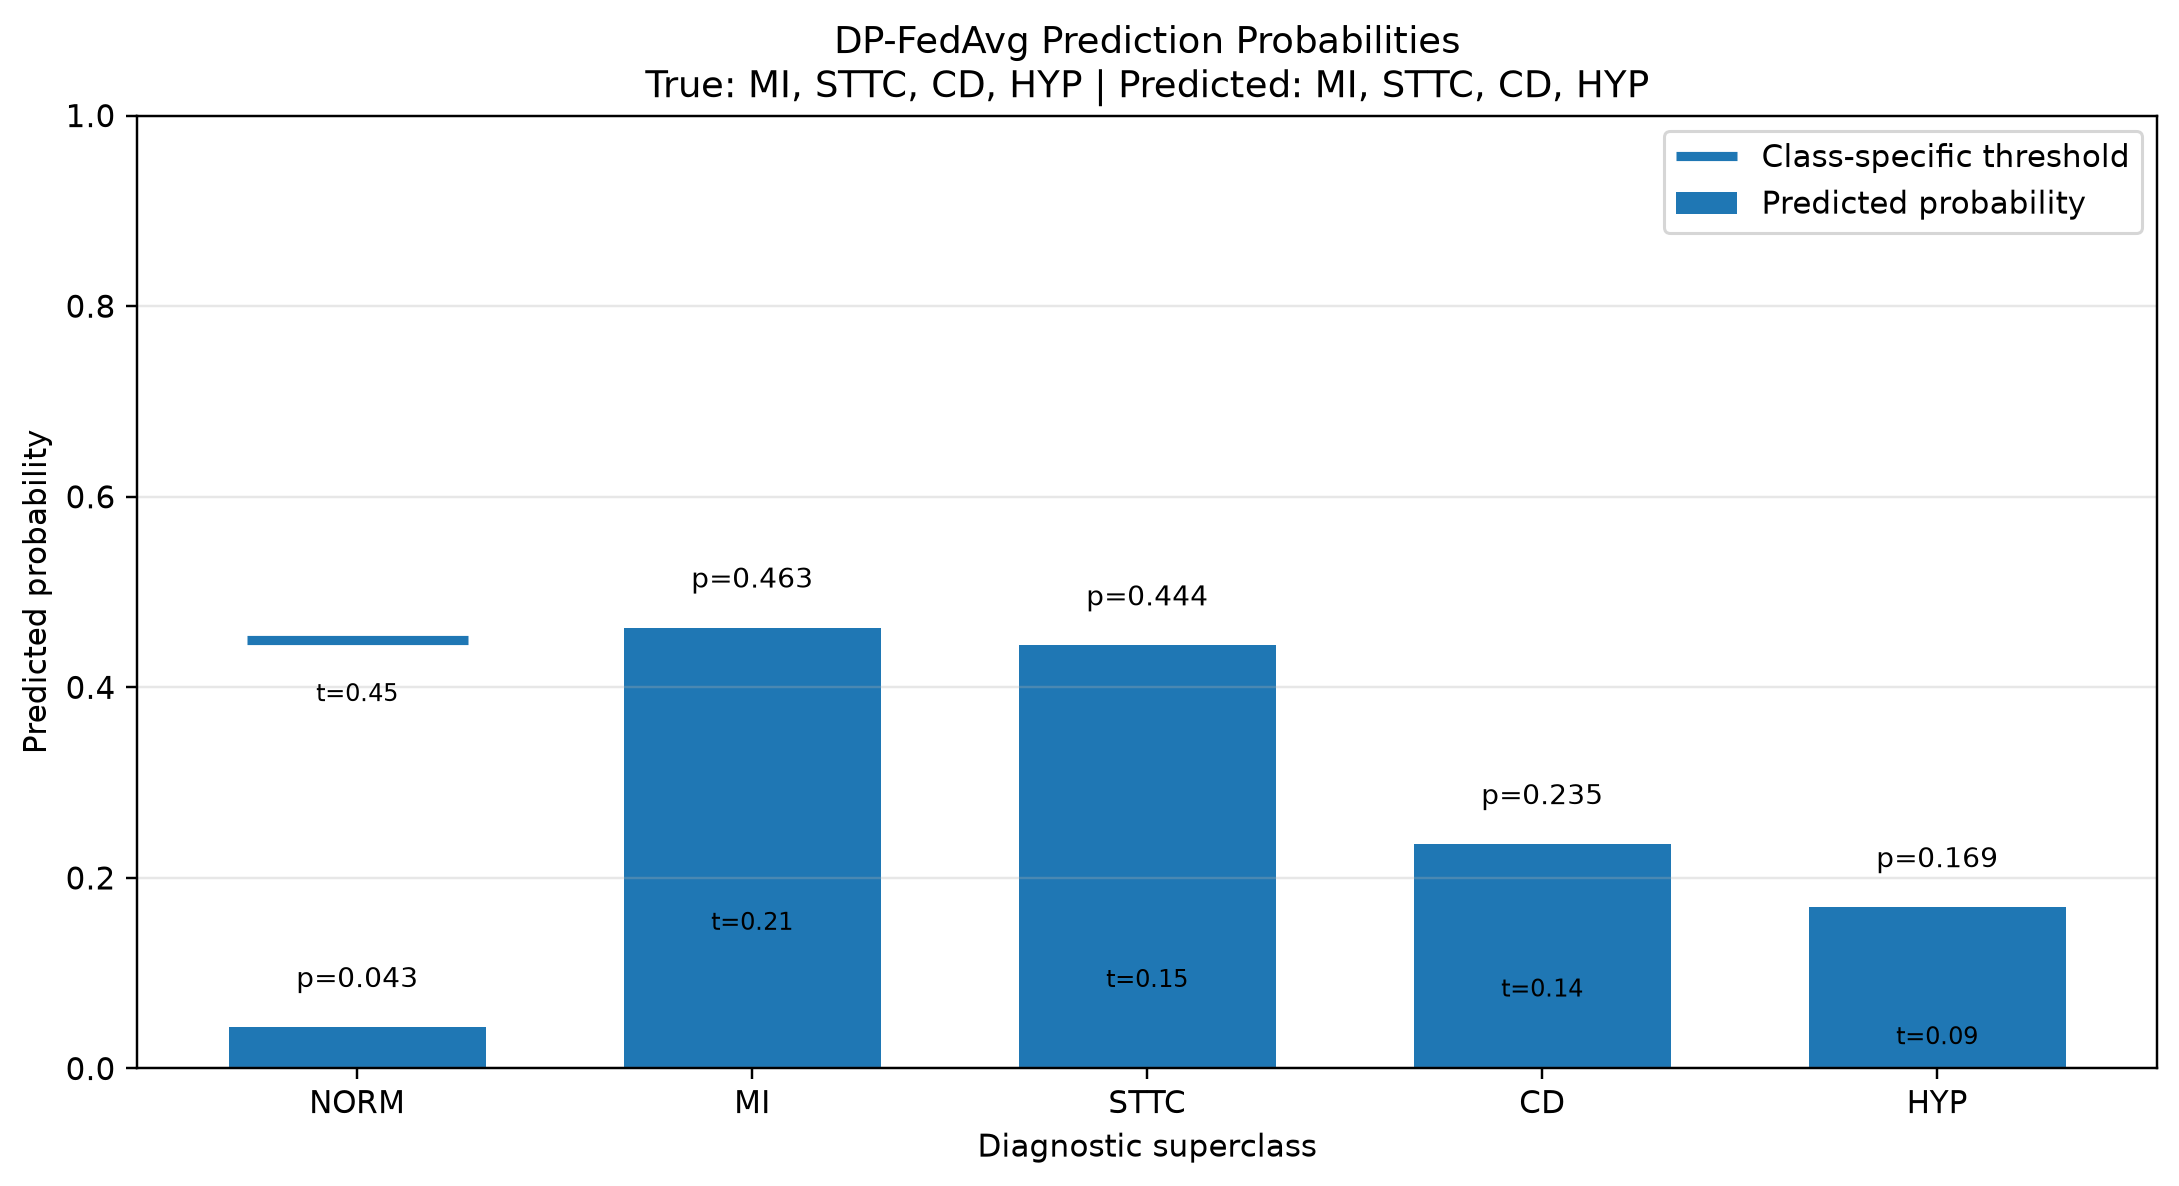


Correct STTC example — ECG 8000


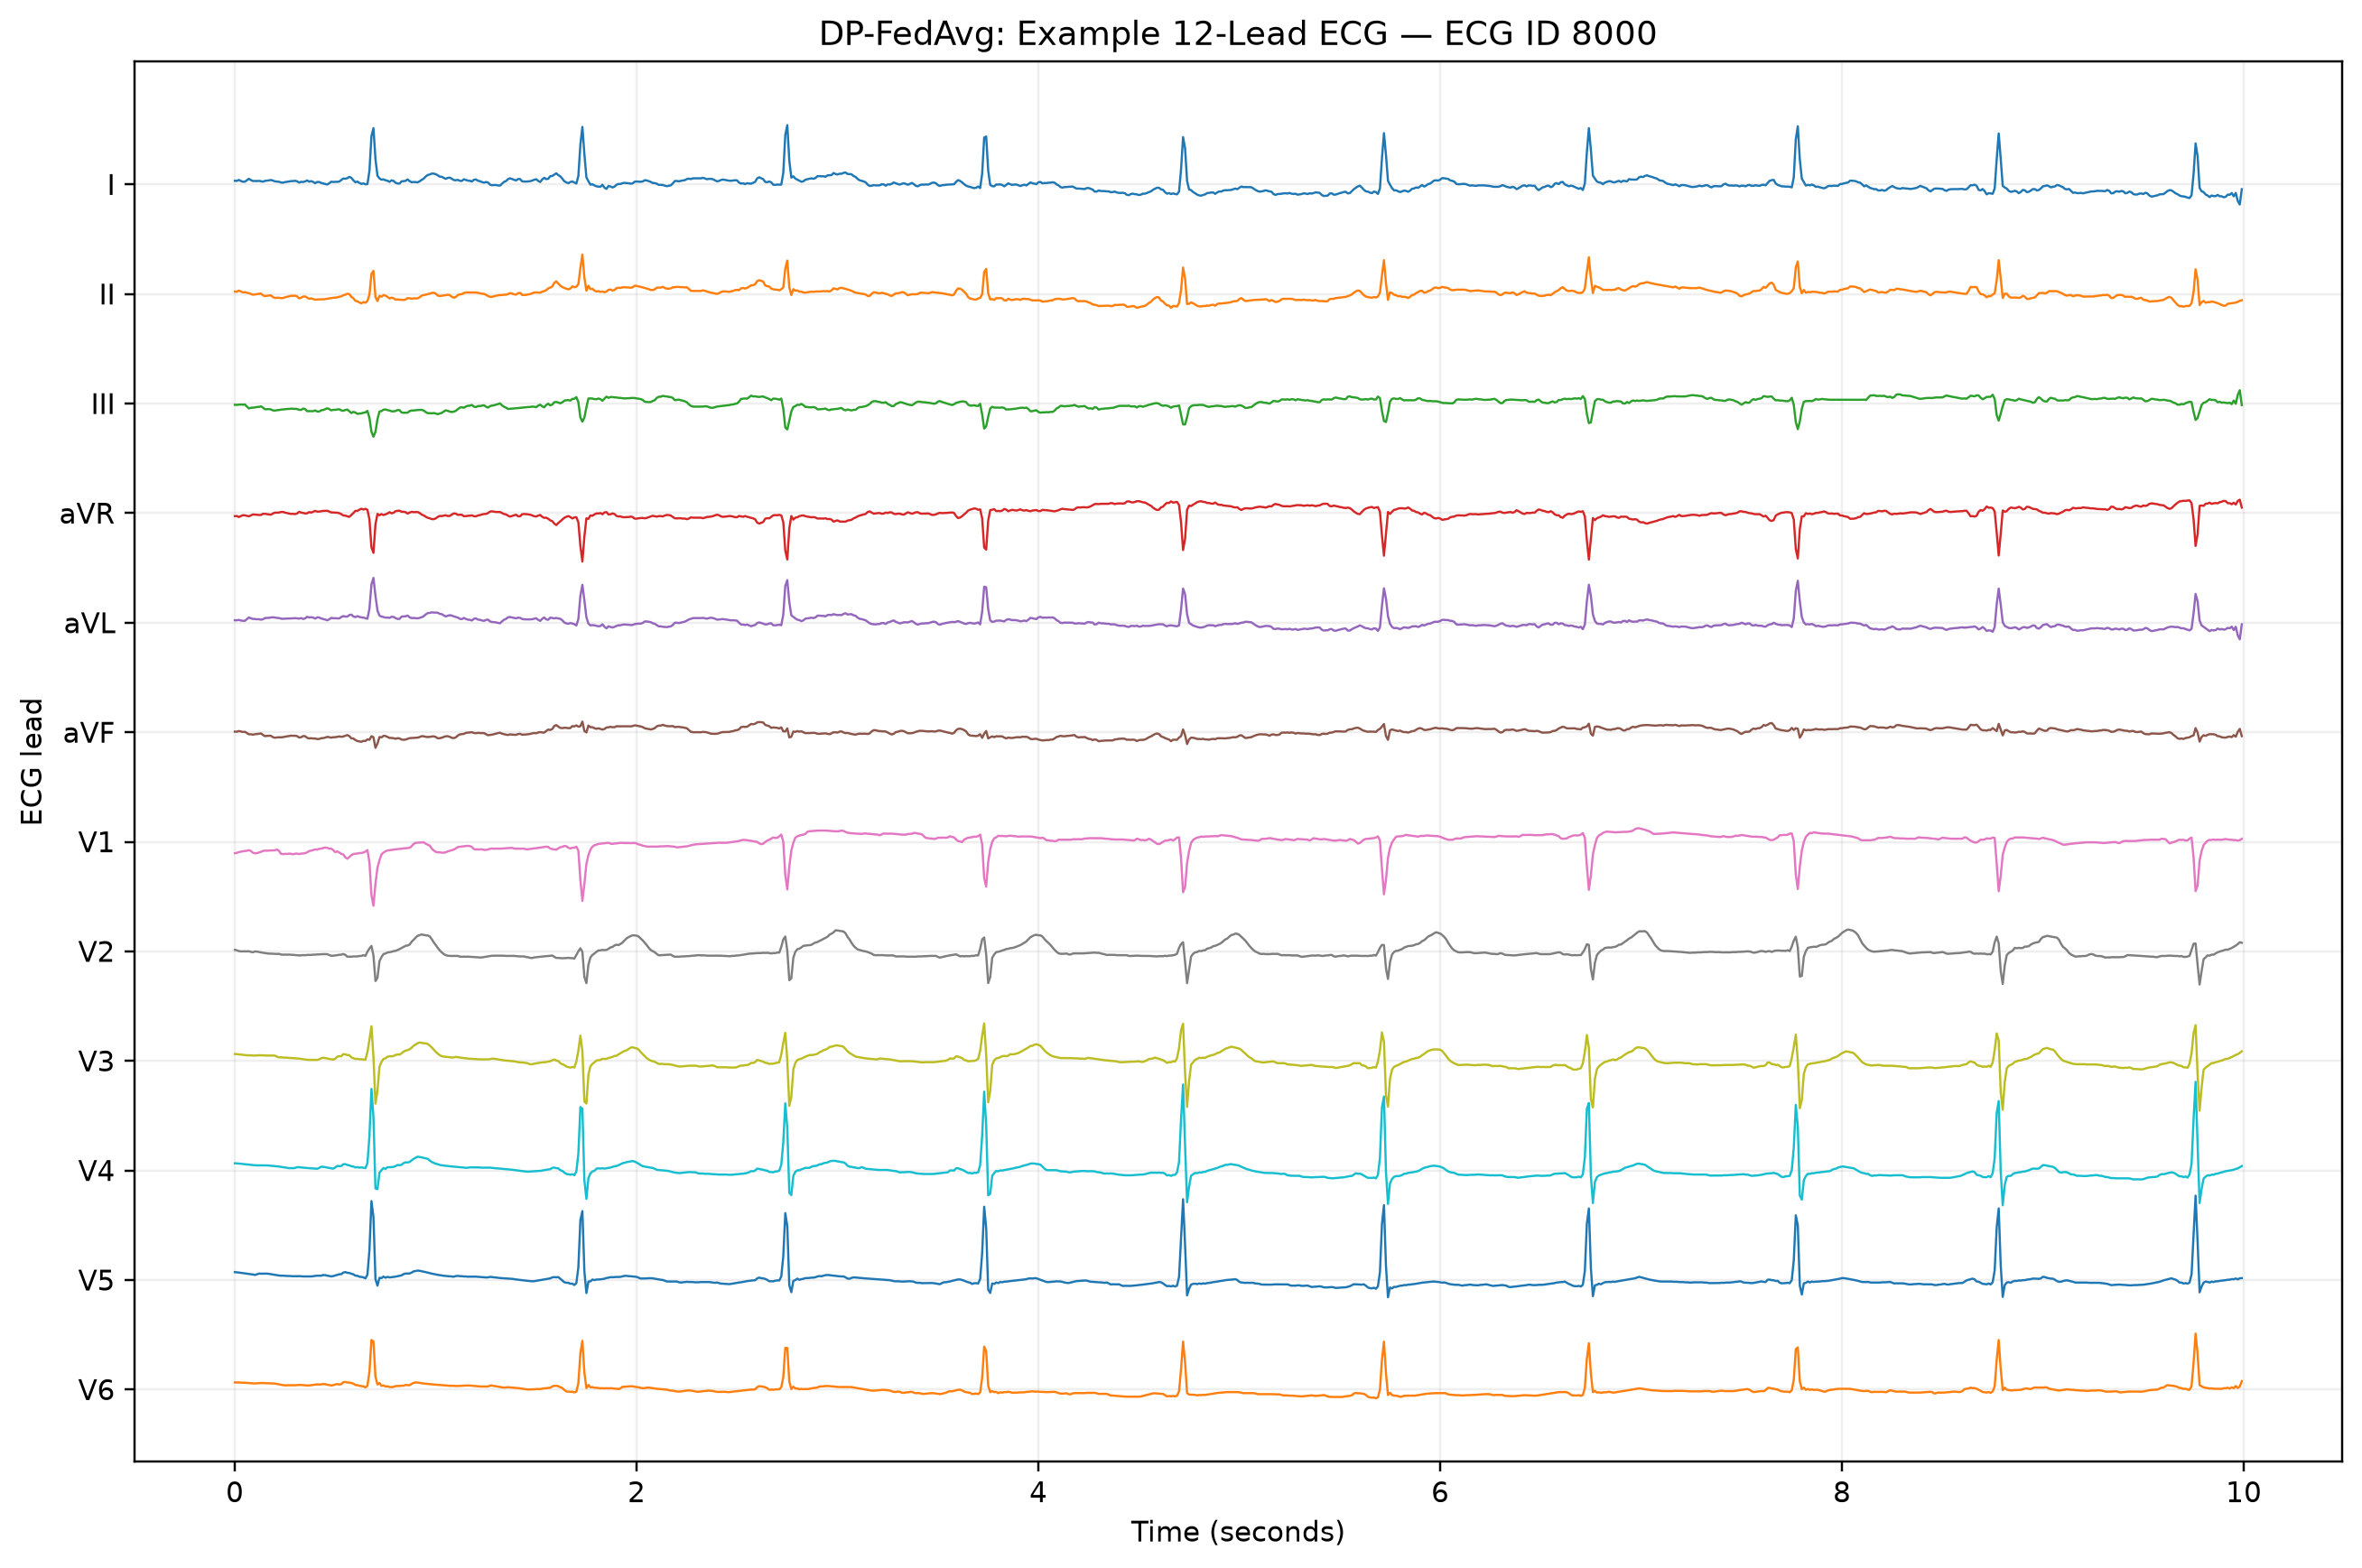

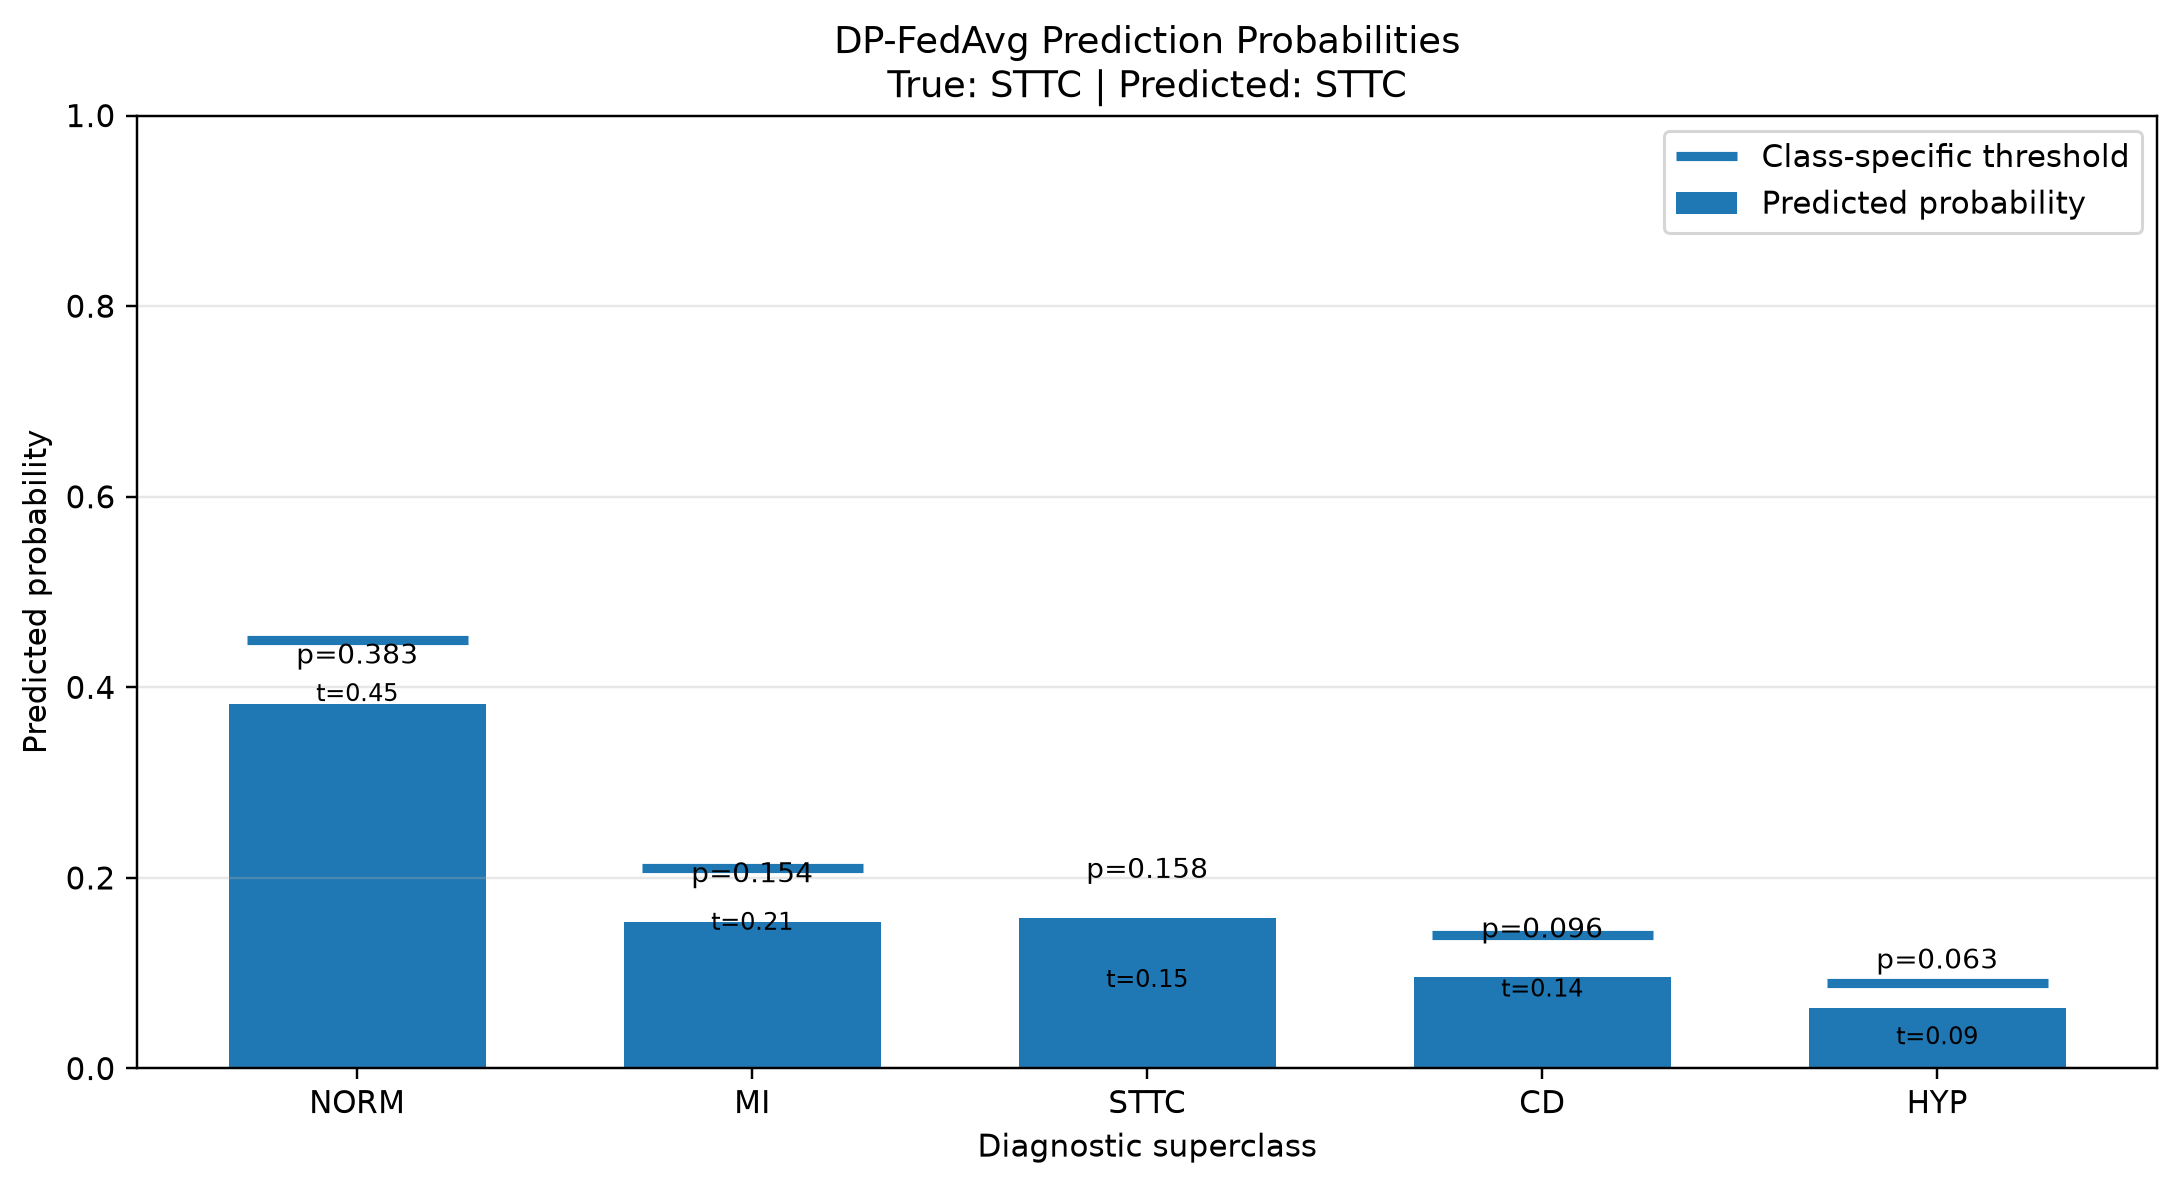

In [8]:
from IPython.display import Image, display

examples = {
    "Correct multi-label example — ECG 5163":
        PROJECT_ROOT / "results" / "predictions" / "example_ecg_5163",
    "Correct STTC example — ECG 8000":
        PROJECT_ROOT / "results" / "predictions" / "example_ecg_8000",
}

for title, directory in examples.items():
    print("\n" + title)
    for filename in ["example_ecg.png", "example_probabilities.png"]:
        path = directory / filename
        if path.exists():
            display(Image(filename=str(path)))
        else:
            print("Missing:", path)


## 11. Discussion



1. FedAvg retained most centralized performance.
2. Compatible FedAvg proved that GroupNorm was not the main cause of private-model degradation.
3. Raw uncertainty-aware weighting did not outperform sample-count FedAvg.
4. DP-SGD created a privacy–utility trade-off.
5. Class-specific thresholds recovered substantial F1 without retraining.
6. Lower thresholds also increased false-positive multi-label predictions.
7. Hospital 3 accumulated privacy loss faster because of its larger sampling ratio.


## 12. Limitations

- One dataset and one main partition.
- One primary random seed.
- Record-level rather than patient-level DP.
- `secure_mode=False`, so the DP implementation is exploratory.
- Threshold calibration may increase false positives.
- No external clinical validation.
- The model is not suitable for clinical use without further validation.


## 13. Conclusion

Standard FedAvg achieved the strongest federated predictive performance while keeping raw ECG data local. Compatible FedAvg showed that the GroupNorm conversion did not cause meaningful utility loss. DP-SGD introduced a measurable record-level privacy guarantee but reduced predictive utility. Raw uncertainty-aware aggregation did not outperform standard FedAvg. Validation-based class-specific threshold calibration substantially improved the DP-FedAvg Macro-F1 without retraining or additional privacy expenditure.


## 14. References

[1] P. Wagner, N. Strodthoff, R.-D. Bousseljot, D. Kreiseler, F. I. Lunze, W. Samek, and T. Schaeffter, “PTB-XL, a large publicly available electrocardiography dataset,” Scientific Data, vol. 7, Art. no. 154, 2020. [Online]. Available: https://doi.org/10.1038/s41597-020-0495-6

[2] C. Dwork, F. McSherry, K. Nissim, and A. Smith, “Calibrating noise to sensitivity in private data analysis,” in Theory of Cryptography Conference (TCC), Lecture Notes in Computer Science, vol. 3876. Berlin, Germany: Springer, 2006, pp. 265–284. [Online]. Available: https://doi.org/10.1007/11681878_14

[3] T. Li, A. K. Sahu, A. Talwalkar, and V. Smith, “Federated learning: Challenges, methods, and future directions,” IEEE Signal Processing Magazine, vol. 37, no. 3, pp. 50–60, May 2020. [Online]. Available: https://doi.org/10.1109/MSP.2020.2975749
